In [ ]:
import sys
sys.path.append("../../../")

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import time

from scipy.stats import invgamma
from scipy.stats import multivariate_normal

from LRM.plotting import set_plot_style
from LRM.CMP import CMP, SmoothedEmpiricalDensity
from LRM.minimax_tilting_sampler import TruncatedMVN


set_plot_style()

SAVE=True


#SKIP TO PLOTTING if you don't want to re-run stuff.

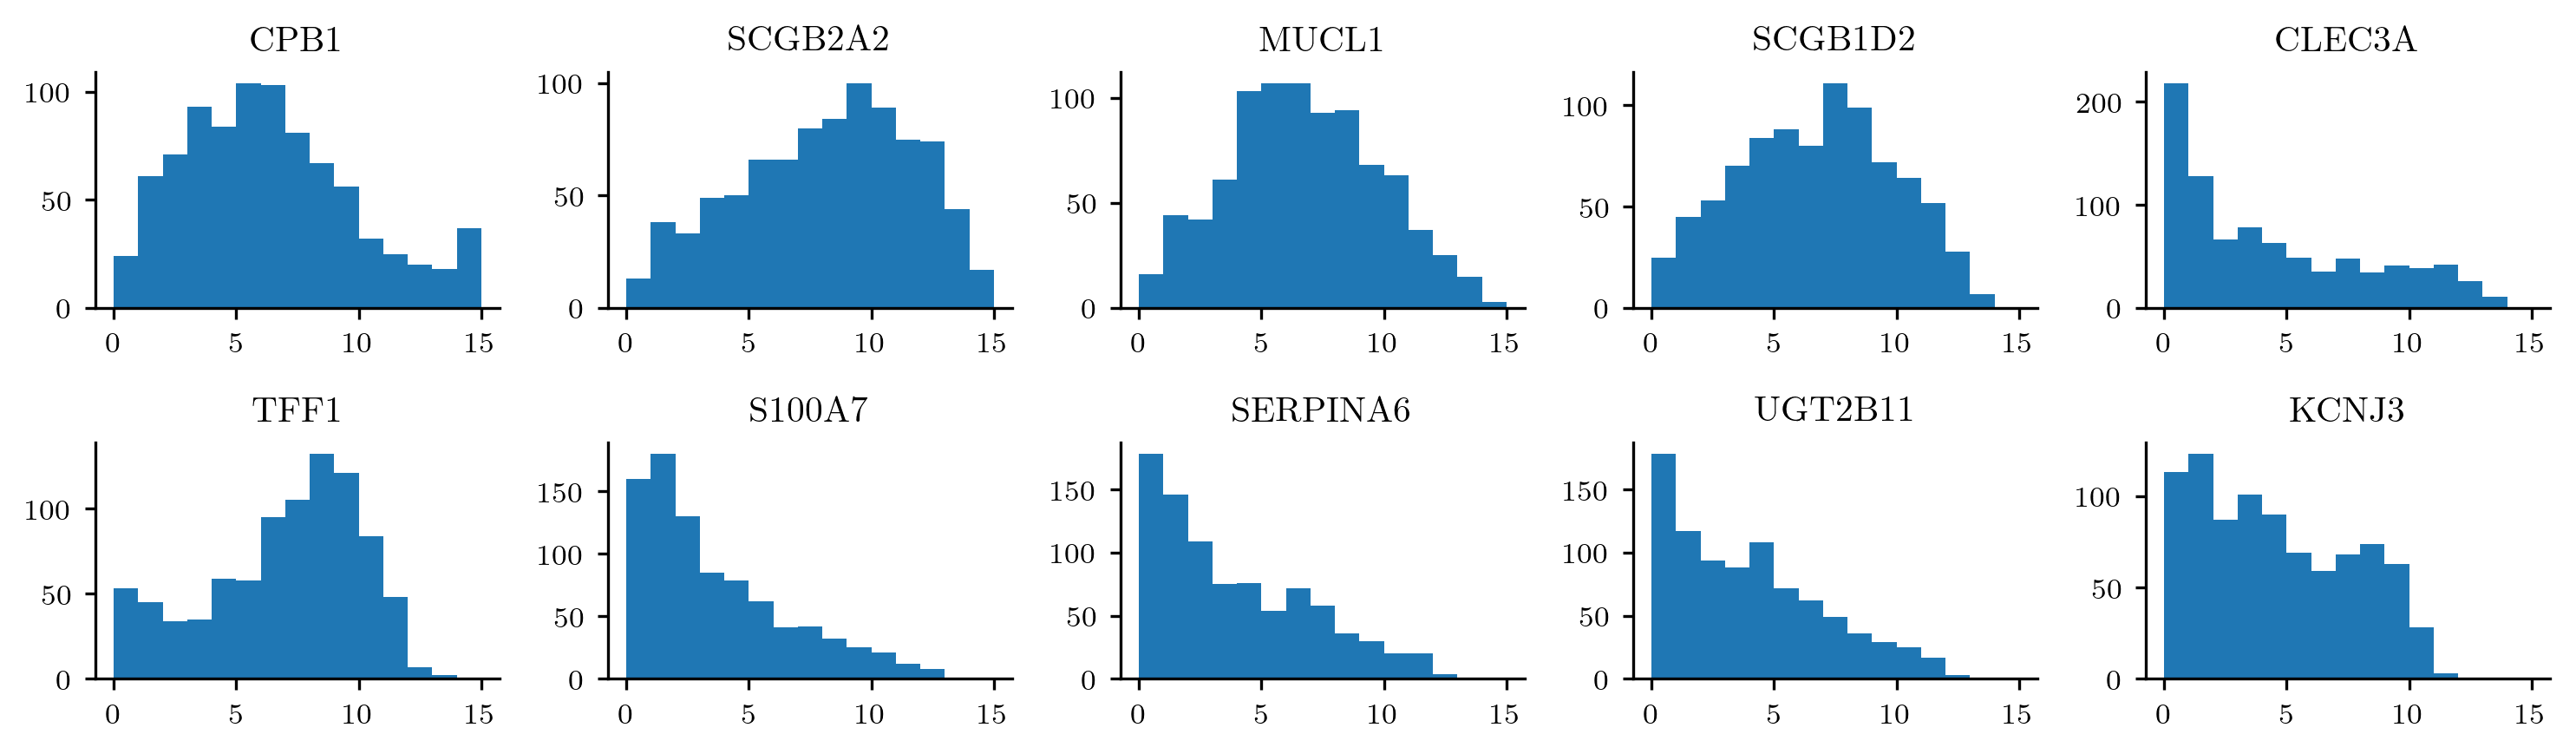

In [34]:
labels = [["CPB1", "SCGB2A2", "MUCL1", "SCGB1D2", "CLEC3A"],["TFF1", "S100A7", "SERPINA6", "UGT2B11", "KCNJ3"]]

def plot_data(samples):
    assert len(samples.shape) == 2 and samples.shape[1] == 10
    fig, axs = plt.subplots(2, 5, figsize=(10,3))

    count = 0
    for i in range(2):
        for j in range(5):
            axs[i, j].hist(samples[:, count], bins=np.arange(16))
            axs[i, j].set_title(labels[i][j])
            count+=1
    
    fig.tight_layout()

raw_data = np.load("../../../data/brca_10.npy").astype(np.int64)
plot_data(raw_data)

## Fitting $\beta$

In [3]:
#Fitting the empirical (and alpha)
alpha = 1.
empirical = SmoothedEmpiricalDensity(alpha=alpha)
empirical.fit(raw_data)

#Setup for M(x)
d = raw_data.shape[1]
j_bound = 2
model = CMP(d=d, empirical=empirical, j_vals=list(range(-j_bound, j_bound + 1)), circular=True)

#Fitting beta with normal prior (coverage)
mu_prior = np.zeros((model.param_size, 1))
Sigma_prior = np.eye(model.param_size)

beta_star, cov, _ = model.fit_coverage(data=raw_data, prior_mean=mu_prior, prior_cov=Sigma_prior, B=50, beta_low=0.1, beta_high=3., verbose=True)

[scipy] beta*: 2.97576, coverage: 0.9800 (target 0.9500); fun=0.0009, success=True


## Posterior

In [15]:
def horseshoe_lrm_gibbs(
    model,
    data,
    beta,
    n_samples,
    burnin=0,
    thin=1,
    hs_idx=None,
    lb=None,
    ub=None,
    seed=None,
):
    """
    Gibbs sampler for LRM-Bayes with Makalic-Schmidt horseshoe prior.

    Uses the same scaling convention as model.posterior(), namely:
        precision = 2 * beta * Lambda + prior_precision

    not:
        precision = 2 * beta * n * Lambda + prior_precision

    Args:
        model: fitted model object with compute_matrices(data).
        data: array of observations.
        beta: learning rate.
        n_samples: number of kept posterior samples.
        burnin: number of burn-in iterations.
        thin: thinning interval.
        hs_idx: indices receiving horseshoe prior. If None, all parameters.
        lb, ub: optional lower/upper bounds for theta-block sampling.
        seed: random seed.

    Returns:
        dict with samples for theta, lambda2, tau2, psi, xi.
    """

    rng = np.random.default_rng(seed)

    Lambda, nu, _ = model.compute_matrices(data=data)

    p = model.param_size

    if hs_idx is None:
        hs_idx = np.arange(p)
    else:
        hs_idx = np.asarray(hs_idx)

    # Initialize
    theta = np.zeros(p)
    lambda2 = np.ones(p)
    psi = np.ones(p)
    tau2 = 1.0
    xi = 1.0

    total_iters = burnin + n_samples * thin

    theta_samples = []
    lambda2_samples = []
    tau2_samples = []
    psi_samples = []
    xi_samples = []

    for it in tqdm(range(total_iters)):

        # ----- theta | lambda, tau, data -----

        prior_prec = np.zeros(p)
        prior_prec[hs_idx] = 1.0 / (tau2 * lambda2[hs_idx])

        Precision = 2.0 * beta * Lambda + np.diag(prior_prec)
        Sigma = np.linalg.inv(Precision)
        mu = Sigma @ (2.0 * beta * nu).reshape(-1)

        if lb is None and ub is None:
            theta = rng.multivariate_normal(mean=mu, cov=Sigma)
        else:
            tmvn = TruncatedMVN(mu, Sigma, lb, ub)
            theta = tmvn.sample(1)

        # ----- lambda_j^2 | theta_j, tau^2, psi_j -----

        for j in hs_idx:
            shape = 1.0
            scale = (1.0 / psi[j]) + (theta[j] ** 2) / (2.0 * tau2)
            lambda2[j] = invgamma.rvs(a=shape, scale=scale, random_state=rng)

        # ----- psi_j | lambda_j^2 -----

        for j in hs_idx:
            shape = 1.0
            scale = 1.0 + 1.0 / lambda2[j]
            psi[j] = invgamma.rvs(a=shape, scale=scale, random_state=rng)

        # ----- tau^2 | theta, lambda, xi -----

        m = len(hs_idx)
        shape = (m + 1.0) / 2.0
        scale = (1.0 / xi) + 0.5 * np.sum(theta[hs_idx] ** 2 / lambda2[hs_idx])
        tau2 = invgamma.rvs(a=shape, scale=scale, random_state=rng)

        # ----- xi | tau^2 -----

        shape = 1.0
        scale = 1.0 + 1.0 / tau2
        xi = invgamma.rvs(a=shape, scale=scale, random_state=rng)

        # ----- store -----

        if it >= burnin and (it - burnin) % thin == 0:
            theta_samples.append(theta.copy())
            lambda2_samples.append(lambda2.copy())
            tau2_samples.append(tau2)
            psi_samples.append(psi.copy())
            xi_samples.append(xi)

    return {
        "theta": np.asarray(theta_samples),
        "lambda2": np.asarray(lambda2_samples),
        "tau2": np.asarray(tau2_samples),
        "psi": np.asarray(psi_samples),
        "xi": np.asarray(xi_samples),
    }

In [16]:
# --------------------------------------------------
# Run horseshoe Gibbs sampler
# --------------------------------------------------

beta = beta_star

lb = np.ones(model.param_size) * -np.inf
ub = np.ones(model.param_size) * np.inf

lb[10:] = 0.0  # positivity constraint, same as before

# Option 1: horseshoe on all parameters
hs_idx = None

# Option 2: horseshoe only on parameters 10 onward
# hs_idx = np.arange(10, model.param_size)

LRM_horseshoe_samples = horseshoe_lrm_gibbs(
    model=model,
    data=raw_data,
    beta=beta,
    n_samples=5_000,
    burnin=1_000,
    thin=1,
    hs_idx=hs_idx,
    lb=lb,
    ub=ub,
    seed=123,
)

np.savez(
    f"outputs/posterior_samples_LRM_horseshoe_calibrated_alpha={alpha}.npz",
    theta=LRM_horseshoe_samples["theta"],
    lambda2=LRM_horseshoe_samples["lambda2"],
    psi=LRM_horseshoe_samples["psi"],
    tau2=LRM_horseshoe_samples["tau2"],
    xi=LRM_horseshoe_samples["xi"],
)

100%|██████████| 6000/6000 [05:33<00:00, 17.97it/s]


## Posterior Predictive

In [17]:
def metropolis_hastings(log_prob, x0, n_samples, proposal_width=1, burn_in=1000, N_MAX=30):
    d = len(x0)
    samples = []
    x = x0.copy()
    log_p_x = log_prob(x)

    for step in tqdm(range(n_samples + burn_in)):
        # Propose a new sample by modifying one random coordinate
        proposal = x.copy()
        idx = np.random.randint(d)
        move = np.random.choice([-proposal_width, proposal_width])
        proposal[idx] = np.clip(proposal[idx] + move, 0, N_MAX)

        log_p_prop = log_prob(proposal)
        accept_ratio = np.exp(log_p_prop - log_p_x)

        if np.random.rand() < accept_ratio:
            x = proposal
            log_p_x = log_p_prop

        if step >= burn_in:
            samples.append(x.copy())

    return np.array(samples)

def thin_chain(samples, thinning_interval):
    return samples[::thinning_interval]

In [24]:
def get_posterior_predictive_LRM_horseshoe(
    hs_samples,
    model,
    raw_data,
    num_predictive_samples=None,
    mh_n_samples=10_000,
    mh_burn_in=5_000,
    thinning_interval=10,
    N_MAX=25,
    seed=None,
):
    """
    Posterior predictive samples using theta draws from horseshoe_lrm_gibbs().
    """

    rng = np.random.default_rng(seed)

    theta_samples = hs_samples["theta"]

    if num_predictive_samples is None:
        num_predictive_samples = raw_data.shape[0]

    predictive_data = []

    for _ in tqdm(range(num_predictive_samples)):

        theta_idx = rng.integers(theta_samples.shape[0])
        #params = theta_samples[theta_idx]
        params = np.asarray(theta_samples[theta_idx]).reshape(-1)

        all_model_data = metropolis_hastings(
            lambda x: model.log_prob(x, params=params),
            x0=raw_data[0],
            n_samples=mh_n_samples,
            burn_in=mh_burn_in,
            N_MAX=N_MAX,
        )

        model_data = thin_chain(
            all_model_data,
            thinning_interval=thinning_interval,
        )

        pred_idx = rng.integers(model_data.shape[0])
        predictive_data.append(model_data[pred_idx])

    return np.stack(predictive_data)

In [25]:
# --------------------------------------------------
# Run posterior predictive simulation
# --------------------------------------------------
RUN_PREDICTIVE = False

if RUN_PREDICTIVE:

    LRM_horseshoe_predictive_data = get_posterior_predictive_LRM_horseshoe(
        hs_samples=LRM_horseshoe_samples,
        model=model,
        raw_data=raw_data,
        num_predictive_samples=raw_data.shape[0],
        mh_n_samples=10_000,
        mh_burn_in=5_000,
        thinning_interval=10,
        N_MAX=25,
        seed=123,
    )

    np.savez(
        f"outputs/posterior_pred_samples_LRM_horseshoe_calibrated_alpha={alpha}.npz",
        model_data=LRM_horseshoe_predictive_data,
    )

100%|██████████| 878/878 [11:11<00:00,  1.31it/s]


## Plotting

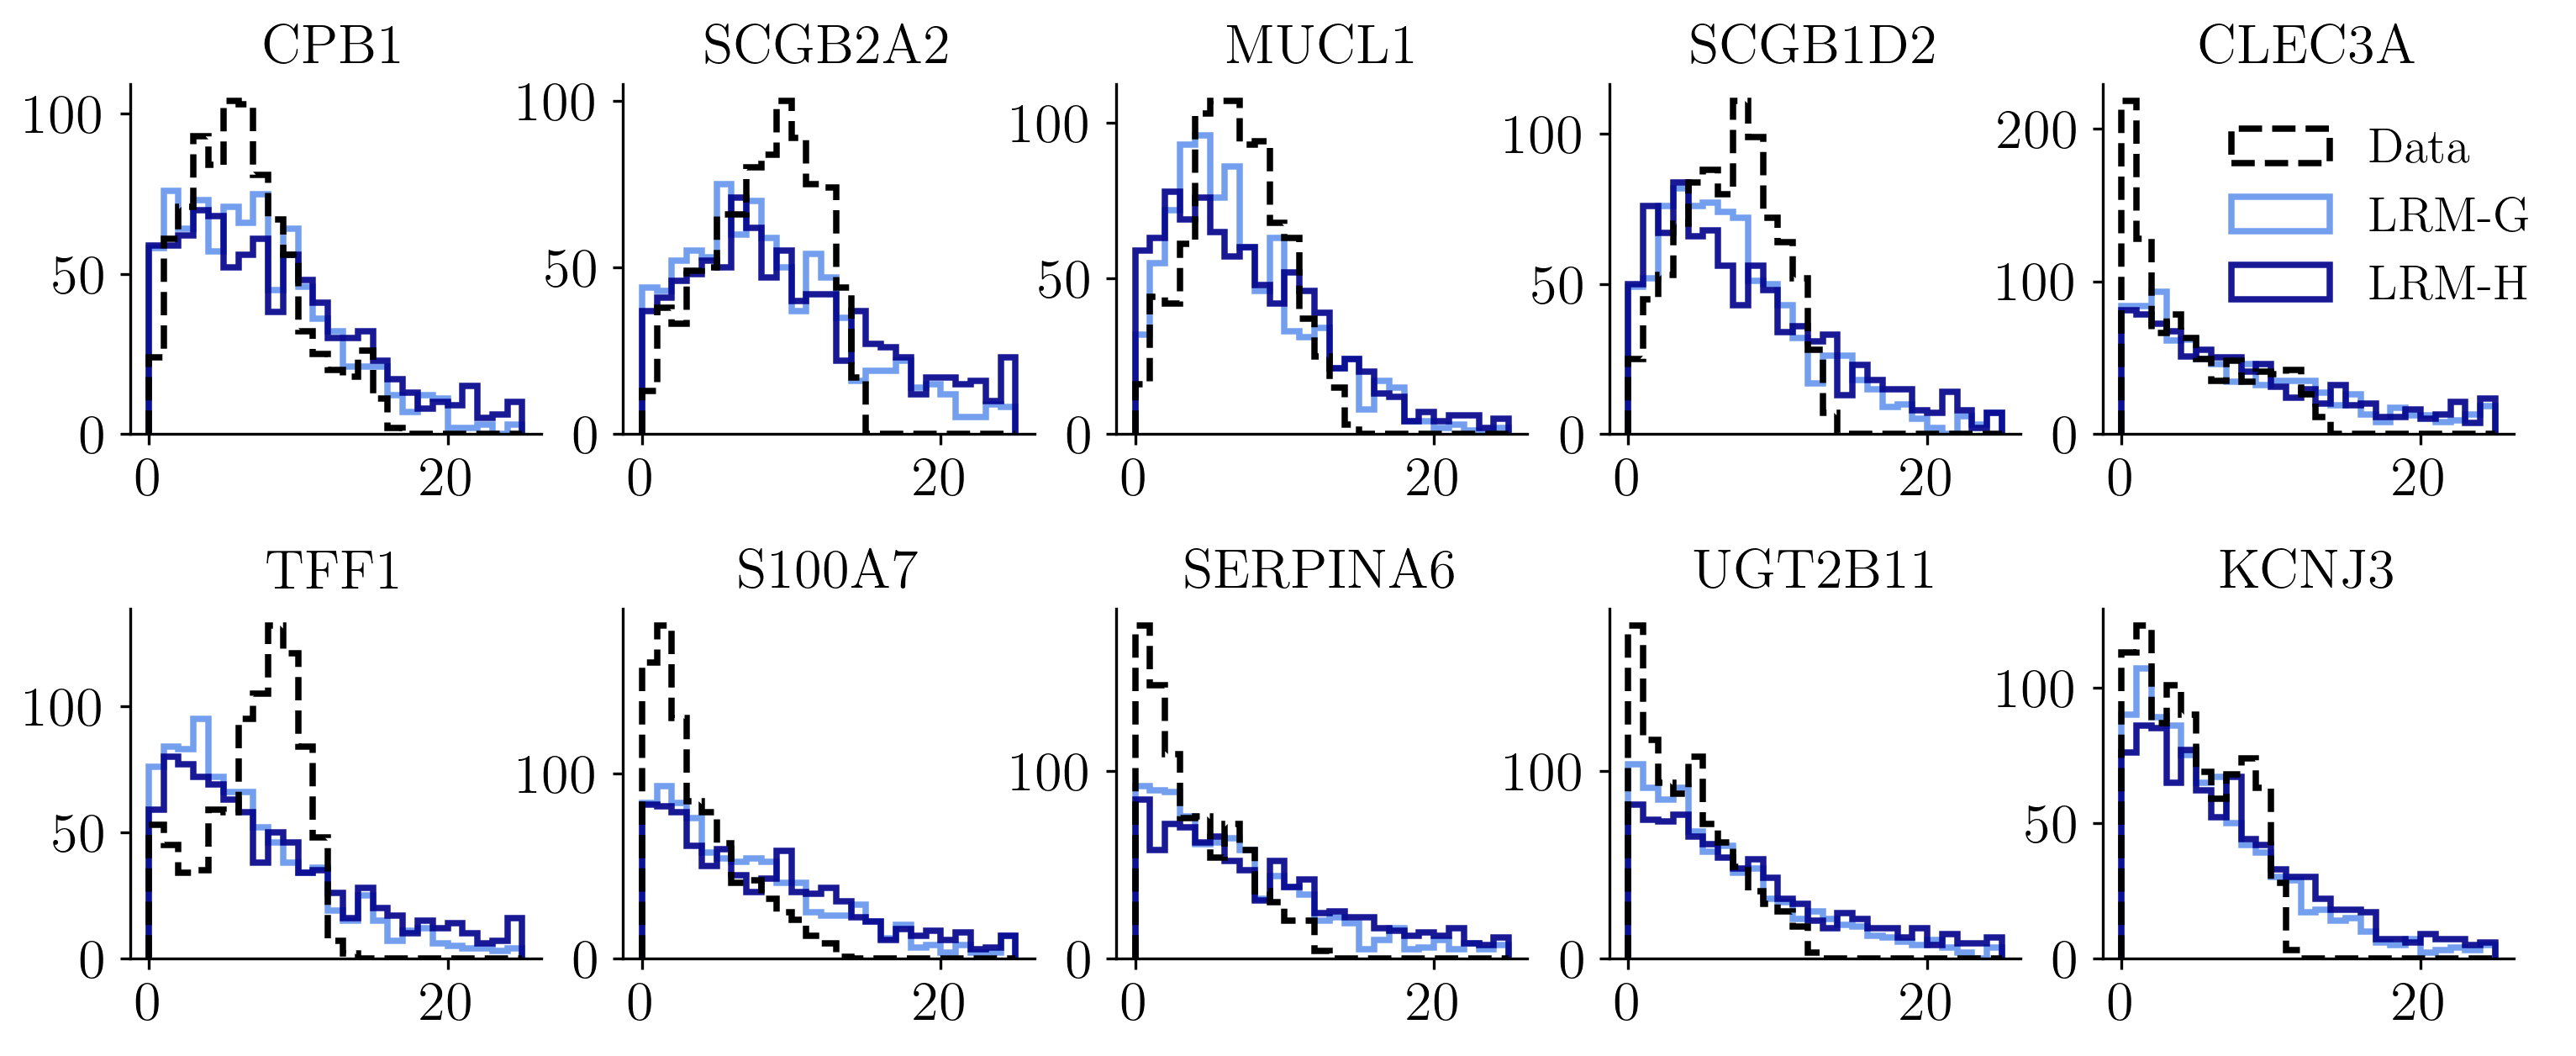

In [35]:
fig, axs = plt.subplots(2, 5, figsize=(12.2,4.5))
labels = [["CPB1", "SCGB2A2", "MUCL1", "SCGB1D2", "CLEC3A"],["TFF1", "S100A7", "SERPINA6", "UGT2B11", "KCNJ3"]]
N_MAX=25
model_data_gaussian_prior = np.load("outputs/posterior_pred_samples_LRM_calibrated_alpha=1.0.npz")["model_data"]
model_data_horseshoe_prior = np.load("outputs/posterior_pred_samples_LRM_horseshoe_calibrated_alpha=1.0.npz")["model_data"]
count = 0
lw = 1.8
for i in range(2):
    for j in range(5):
        axs[i, j].hist(raw_data[:, count], histtype='step', bins=np.arange(N_MAX+1), label="Data",color='black', linestyle='--', linewidth=lw, zorder=3)
        axs[i, j].hist(model_data_gaussian_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-G", color='cornflowerblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)
        axs[i, j].hist(model_data_horseshoe_prior[:, count], histtype='step', bins=np.arange(N_MAX+1), label="LRM-H", color='darkblue', linestyle='-', linewidth=lw, alpha=0.9, zorder=1)
        axs[i, j].set_title(labels[i][j], fontsize=16)
        count+=1

axs[0,-1].legend(frameon=False, fontsize=14, bbox_to_anchor=(1.15, 1))

for ax in axs.flat:
    ax.tick_params(axis='both', labelsize=16)

fig.subplots_adjust(hspace=0.5)

if SAVE:
    plt.savefig("./results/BRCA-fit.pdf", format='pdf', bbox_inches='tight')